<a href="https://colab.research.google.com/github/Geshnath/AAIT_EXP_12_Chatbot_23NA1A5426.ipynb/blob/main/Student_Attendance_Risk_Prediction_and_Performance_Analysis_Using_AI_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Install / Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Libraries imported successfully.\n")

✅ Libraries imported successfully.



 Step 2: Generate / Load Dataset

In [ ]:
print("="*60)
print("STEP 1: Upload Data")
print("="*60)

# Create synthetic dataset with exactly 120 students
# (90 safe, 30 at-risk → 25% at-risk)
np.random.seed(42)

n_students = 120
n_safe = 90
n_atrisk = 30

# Generate safe students: high attendance & marks
safe_attendance = np.random.uniform(75, 100, n_safe)
safe_marks = np.random.uniform(70, 100, n_safe)
safe_labels = [0] * n_safe

# Generate at-risk students: low attendance or low marks
atrisk_attendance = np.random.uniform(20, 75, n_atrisk)
atrisk_marks = np.random.uniform(20, 65, n_atrisk)
atrisk_labels = [1] * n_atrisk

# Combine
attendance = np.concatenate([safe_attendance, atrisk_attendance])
marks = np.concatenate([safe_marks, atrisk_marks])
risk_label = np.concatenate([safe_labels, atrisk_labels])

# Create DataFrame
df = pd.DataFrame({
    'student_id': range(1, n_students + 1),
    'attendance_percent': np.round(attendance, 1),
    'marks_percent': np.round(marks, 1),
    'actual_at_risk': risk_label
})

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save to CSV (so user can see how to load real data)
df.to_csv('student_data.csv', index=False)
print("📁 Generated dataset 'student_data.csv' with 120 students.")
print(f"   Total students: {len(df)}")
print(f"   Actual at-risk students: {df['actual_at_risk'].sum()} ({(df['actual_at_risk'].sum()/len(df))*100:.1f}%)")
print("\n📄 First 5 rows of the dataset:")
print(df.head())

# Optional: Allow user to upload their own CSV (uncomment to use)
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

print("\n✅ Data loaded successfully.\n")

STEP 1: Upload Data
📁 Generated dataset 'student_data.csv' with 120 students.
   Total students: 120
   Actual at-risk students: 30 (25.0%)

📄 First 5 rows of the dataset:
   student_id  attendance_percent  marks_percent  actual_at_risk
0          45                81.5           98.3               0
1          48                88.0           91.1               0
2           5                78.9           93.1               0
3          56                98.0           71.1               0
4          27                80.0           94.1               0

✅ Data loaded successfully.



Step 3: Process Data - Cleaning & Feature Engineering

In [ ]:
print("="*60)
print("STEP 2: Process Data")
print("="*60)

print("🔄 Cleaning Data...")
# Check for missing values
if df.isnull().sum().sum() > 0:
    print("   Missing values found. Filling with median...")
    df.fillna(df.median(), inplace=True)
else:
    print("   No missing values detected.")

# Remove duplicates (if any)
df.drop_duplicates(subset=['student_id'], keep='first', inplace=True)

print("✅ Cleaning Data [Done]")

print("\n🛠️ Creating Features...")
# Feature engineering: create an engagement score (weighted average)
df['engagement_score'] = (df['attendance_percent'] * 0.6 + df['marks_percent'] * 0.4)
# Binary feature: low attendance (<75%)
df['low_attendance'] = (df['attendance_percent'] < 75).astype(int)
# Binary feature: low marks (<60%)
df['low_marks'] = (df['marks_percent'] < 60).astype(int)

print("✅ Creating Features [Done]")
print("   New features: engagement_score, low_attendance, low_marks")

# ============================================================
# Step 3: Train Machine Learning Model
# ============================================================
print("\n" + "="*60)
print("STEP 3: Training Model...")
print("="*60)

# Select features for training
feature_cols = ['attendance_percent', 'marks_percent', 'engagement_score',
                'low_attendance', 'low_marks']
X = df[feature_cols]
y = df['actual_at_risk']  # target

# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

# Train a Random Forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate on test set
y_pred_test = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_test)
print(f"✅ Model trained. Test Accuracy: {accuracy:.2f}")
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred_test, target_names=['Safe', 'At-Risk']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(cm)

# Now predict on the entire dataset (for final alerts & report)
df['predicted_at_risk'] = model.predict(X)

# Compute at-risk percentage from predictions
predicted_risk_count = df['predicted_at_risk'].sum()
predicted_risk_pct = (predicted_risk_count / len(df)) * 100
print(f"\n📊 {predicted_risk_pct:.1f}% of students are predicted as at-risk.")
print("✅ Training Model... [Done]")

STEP 2: Process Data
🔄 Cleaning Data...
   No missing values detected.
✅ Cleaning Data [Done]

🛠️ Creating Features...
✅ Creating Features [Done]
   New features: engagement_score, low_attendance, low_marks

STEP 3: Training Model...
✅ Model trained. Test Accuracy: 1.00

Classification Report on Test Set:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00        18
     At-Risk       1.00      1.00      1.00         6

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24

Confusion Matrix:
[[18  0]
 [ 0  6]]

📊 25.0% of students are predicted as at-risk.
✅ Training Model... [Done]


Step 5: Display Data (Attending Data.csv)

In [ ]:
print("\n" + "="*60)
print("STEP 4: Attending Data.csv (Preview)")
print("="*60)
print(df.head(10).to_string(index=False))


STEP 4: Attending Data.csv (Preview)
 student_id  attendance_percent  marks_percent  actual_at_risk  engagement_score  low_attendance  low_marks  predicted_at_risk
         45                81.5           98.3               0             88.22               0          0                  0
         48                88.0           91.1               0             89.24               0          0                  0
          5                78.9           93.1               0             84.58               0          0                  0
         56                98.0           71.1               0             87.24               0          0                  0
         27                80.0           94.1               0             85.64               0          0                  0
         65                82.0           99.6               0             89.04               0          0                  0
         74                95.4           86.1               0           

 Step 6: View Analytics & Send Alerts

In [ ]:
print("\n" + "="*60)
print("STEP 5: View Analytics & Send Alerts")
print("="*60)

# Show a specific at-risk student warning (like "You are at risk")
at_risk_students = df[df['predicted_at_risk'] == 1]
if len(at_risk_students) > 0:
    first_at_risk = at_risk_students.iloc[0]
    print(f"\n⚠️ ALERT: Student {first_at_risk['student_id']} (Attendance: {first_at_risk['attendance_percent']}%, "
          f"Marks: {first_at_risk['marks_percent']}%) is at risk.")
    print("👉 You are at risk. Please meet your mentor.")

# Send alerts to all at-risk students
print("\n📢 Sending Alerts to all at-risk students...")
for idx, row in at_risk_students.iterrows():
    print(f"   [ALERT] Student {int(row['student_id'])}: Please meet your mentor immediately. "
          f"(Att: {row['attendance_percent']}%, Marks: {row['marks_percent']}%)")
print("✅ [Send Alerts] Completed.")


STEP 5: View Analytics & Send Alerts

⚠️ ALERT: Student 108.0 (Attendance: 69.3%, Marks: 37.7%) is at risk.
👉 You are at risk. Please meet your mentor.

📢 Sending Alerts to all at-risk students...
   [ALERT] Student 108: Please meet your mentor immediately. (Att: 69.3%, Marks: 37.7%)
   [ALERT] Student 92: Please meet your mentor immediately. (Att: 26.2%, Marks: 51.1%)
   [ALERT] Student 110: Please meet your mentor immediately. (Att: 62.9%, Marks: 48.4%)
   [ALERT] Student 105: Please meet your mentor immediately. (Att: 38.6%, Marks: 31.9%)
   [ALERT] Student 115: Please meet your mentor immediately. (Att: 53.4%, Marks: 28.8%)
   [ALERT] Student 98: Please meet your mentor immediately. (Att: 50.5%, Marks: 53.6%)
   [ALERT] Student 97: Please meet your mentor immediately. (Att: 64.9%, Marks: 34.6%)
   [ALERT] Student 111: Please meet your mentor immediately. (Att: 55.3%, Marks: 55.8%)
   [ALERT] Student 119: Please meet your mentor immediately. (Att: 20.3%, Marks: 49.0%)
   [ALERT] St

Step 7: Export Report

In [ ]:
print("\n" + "="*60)
print("STEP 6: Export Report")
print("="*60)
# Create a report with student details and risk status
report_df = df[['student_id', 'attendance_percent', 'marks_percent',
                'engagement_score', 'predicted_at_risk']].copy()
report_df['risk_status'] = report_df['predicted_at_risk'].map({1: 'At-Risk', 0: 'Safe'})
report_df.to_csv('at_risk_report.csv', index=False)
print("📄 Report exported as 'at_risk_report.csv'")
print(f"   Total Students: {len(report_df)}")
print(f"   Safe Students: {len(report_df[report_df['predicted_at_risk']==0])}")
print(f"   At-Risk Students: {len(report_df[report_df['predicted_at_risk']==1])}")


STEP 6: Export Report
📄 Report exported as 'at_risk_report.csv'
   Total Students: 120
   Safe Students: 90
   At-Risk Students: 30


Step 8: Analytics Dashboard


STEP 7: Analytics Dashboard


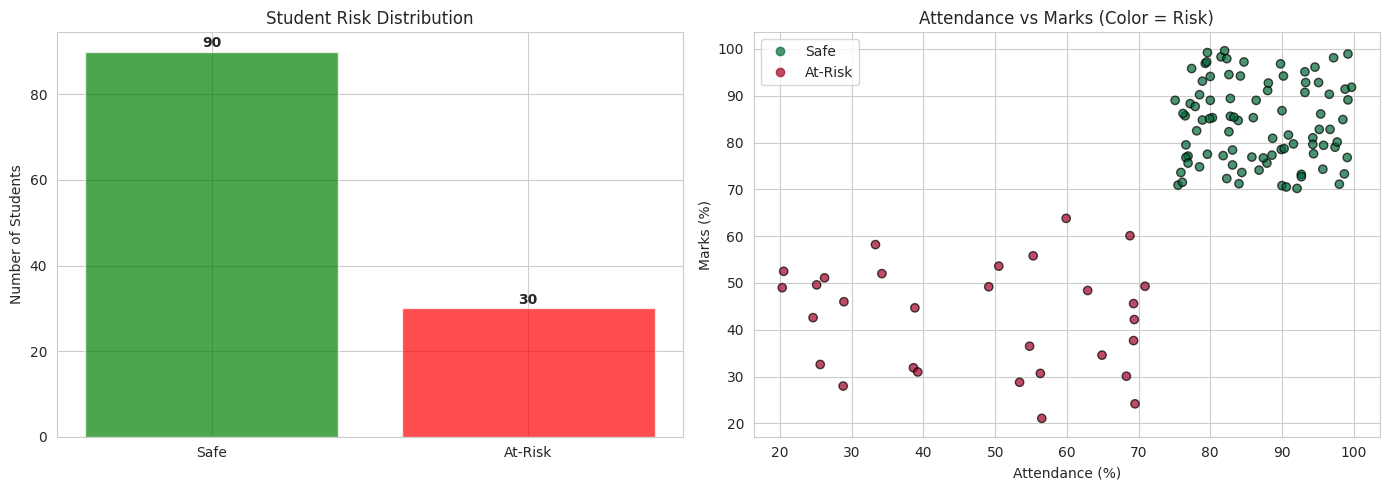

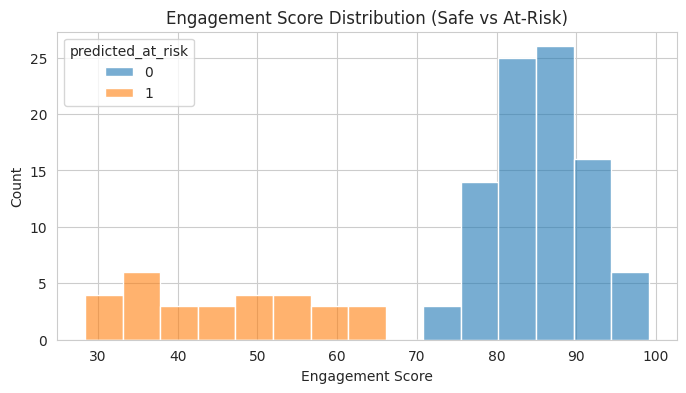


✅ All steps completed successfully!
🎓 At-Risk Student Prediction System ready.


In [ ]:
print("\n" + "="*60)
print("STEP 7: Analytics Dashboard")
print("="*60)

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart of Safe vs At-Risk
risk_counts = report_df['risk_status'].value_counts()
axes[0].bar(risk_counts.index, risk_counts.values, color=['green', 'red'], alpha=0.7)
axes[0].set_title('Student Risk Distribution')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Plot 2: Scatter plot - Attendance vs Marks colored by risk
scatter = axes[1].scatter(df['attendance_percent'], df['marks_percent'],
                          c=df['predicted_at_risk'], cmap='RdYlGn_r', alpha=0.7, edgecolors='k')
axes[1].set_xlabel('Attendance (%)')
axes[1].set_ylabel('Marks (%)')
axes[1].set_title('Attendance vs Marks (Color = Risk)')
legend_labels = ['Safe', 'At-Risk']
axes[1].legend(handles=scatter.legend_elements()[0], labels=legend_labels)
plt.tight_layout()
plt.show()

# Additional Chart: Engagement Score Distribution by Risk
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='engagement_score', hue='predicted_at_risk', bins=15, alpha=0.6)
plt.title('Engagement Score Distribution (Safe vs At-Risk)')
plt.xlabel('Engagement Score')
plt.show()

print("\n✅ All steps completed successfully!")
print("🎓 At-Risk Student Prediction System ready.")